可视化dyngen(batch)

In [1]:
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

In [2]:
data = 'dyngen/batch-dataset_modified'
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
save_dir = '../figures/dyngen/batch'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [3]:
cluster_key = 'progress'
basis = 'umap'

In [4]:
import numpy as np

创建AnnData列表

In [5]:
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
adata_list = []
vkey_list = []
titles = []
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    adata_path = f'{base_dir}/{data}/{model}/{model_name}.h5ad'
    adata = sc.read_h5ad(adata_path)
    vkey = f'{model_name}_velocity'
    if model == 'scvelo':
        adata = adata[:, adata.var["velocity_genes"]].copy()
    # if model == 'topovelo':
    #     adata = adata[(adata.layers[vkey] != 0).any(axis=1)].copy()
    #     del adata.uns['neighbors']
    #     del adata.obsp[spatial_graph_key]
    if model == 'unitvelo':
        adata = adata[:, ~np.isnan(adata.layers[vkey]).any(axis=0)].copy()
    scv.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
    scv.tl.velocity_graph(adata, vkey=vkey, n_jobs=20)
    adata_list.append(adata)
    vkey_list.append(vkey)
    titles.append(model)
    if model == 'stt':
        adata_aggr_path = f'{base_dir}/{data}/{model}/stt_aggr.h5ad'
        adata_aggr = sc.read_h5ad(adata_aggr_path)
        vkey_aggr = 'vj'
        adata_aggr.obs.index = adata.obs.index
        adata_aggr.obs[cluster_key] = adata.obs[cluster_key]
        adata_aggr.obsm[f'X_{basis}'] = adata.obsm[f'X_{basis}']
        adata_aggr.uns['neighbors'] = adata.uns['neighbors']
        adata_aggr.obsp['distances'] = adata.obsp['distances']
        adata_aggr.obsp['connectivities'] = adata.obsp['connectivities']
        scv.tl.velocity_graph(adata_aggr, vkey=vkey_aggr, n_jobs=8)
        adata_list.append(adata_aggr)
        vkey_list.append(vkey_aggr)
        titles.append('stt(vj)')
    if model == 'latentvelo':
        adata_lt_path = f'{base_dir}/{data}/{model}/latent_adata.h5ad'
        adata_lt = sc.read_h5ad(adata_lt_path)
        vkey_lt = 'spliced_velocity'
        adata_lt.obs[cluster_key] = adata.obs[cluster_key]
        adata_lt.obsm[f'X_{basis}'] = adata.obsm[f'X_{basis}']
        adata_lt.uns['neighbors'] = adata.uns['neighbors']
        adata_lt.obsp['distances'] = adata.obsp['distances']
        adata_lt.obsp['connectivities'] = adata.obsp['connectivities']
        scv.tl.velocity_graph(adata_lt, vkey=vkey_lt, n_jobs=8)
        adata_list.append(adata_lt)
        vkey_list.append(vkey_lt)
        titles.append('latentvelo(lt)')

computing neighbors


2025-05-09 21:34:43.261017: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 21:34:43.278649: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-09 21:34:43.283754: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 21:34:44.310310: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


100%|██████████| 4000/4000 [00:07<00:00, 516.75cells/s] 


    finished (0:00:08) --> added 
    'scvelo_dynamical_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


...

    finished (0:00:03) --> added 
    'stt_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity graph (using 8/104 cores)


100%|██████████| 4000/4000 [00:09<00:00, 404.89cells/s] 


    finished (0:00:11) --> added 
    'vj_graph', sparse matrix with cosine correlations (adata.uns)
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 20/104 cores)


100%|██████████| 4000/4000 [00:10<00:00, 392.49cells/s] 


    finished (0:00:11) --> added 
    'velovgi_velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

速度和时间一起画

computing velocity embedding
    finished (0:00:00) --> added
    'scvelo_dynamical_velocity_umap', embedded velocity vectors (adata.obsm)


/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs

computing velocity embedding
    finished (0:00:00) --> added
    'unitvelo_velocity_umap', embedded velocity vectors (adata.obsm)


/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs

computing velocity embedding
    finished (0:00:00) --> added
    'velovae_velocity_umap', embedded velocity vectors (adata.obsm)


...

/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs

computing velocity embedding
    finished (0:00:00) --> added
    'vj_umap', embedded velocity vectors (adata.obsm)


/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


computing velocity embedding
    finished (0:00:00) --> added
    'velovgi_velocity_umap', embedded velocity vectors (adata.obsm)


/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs

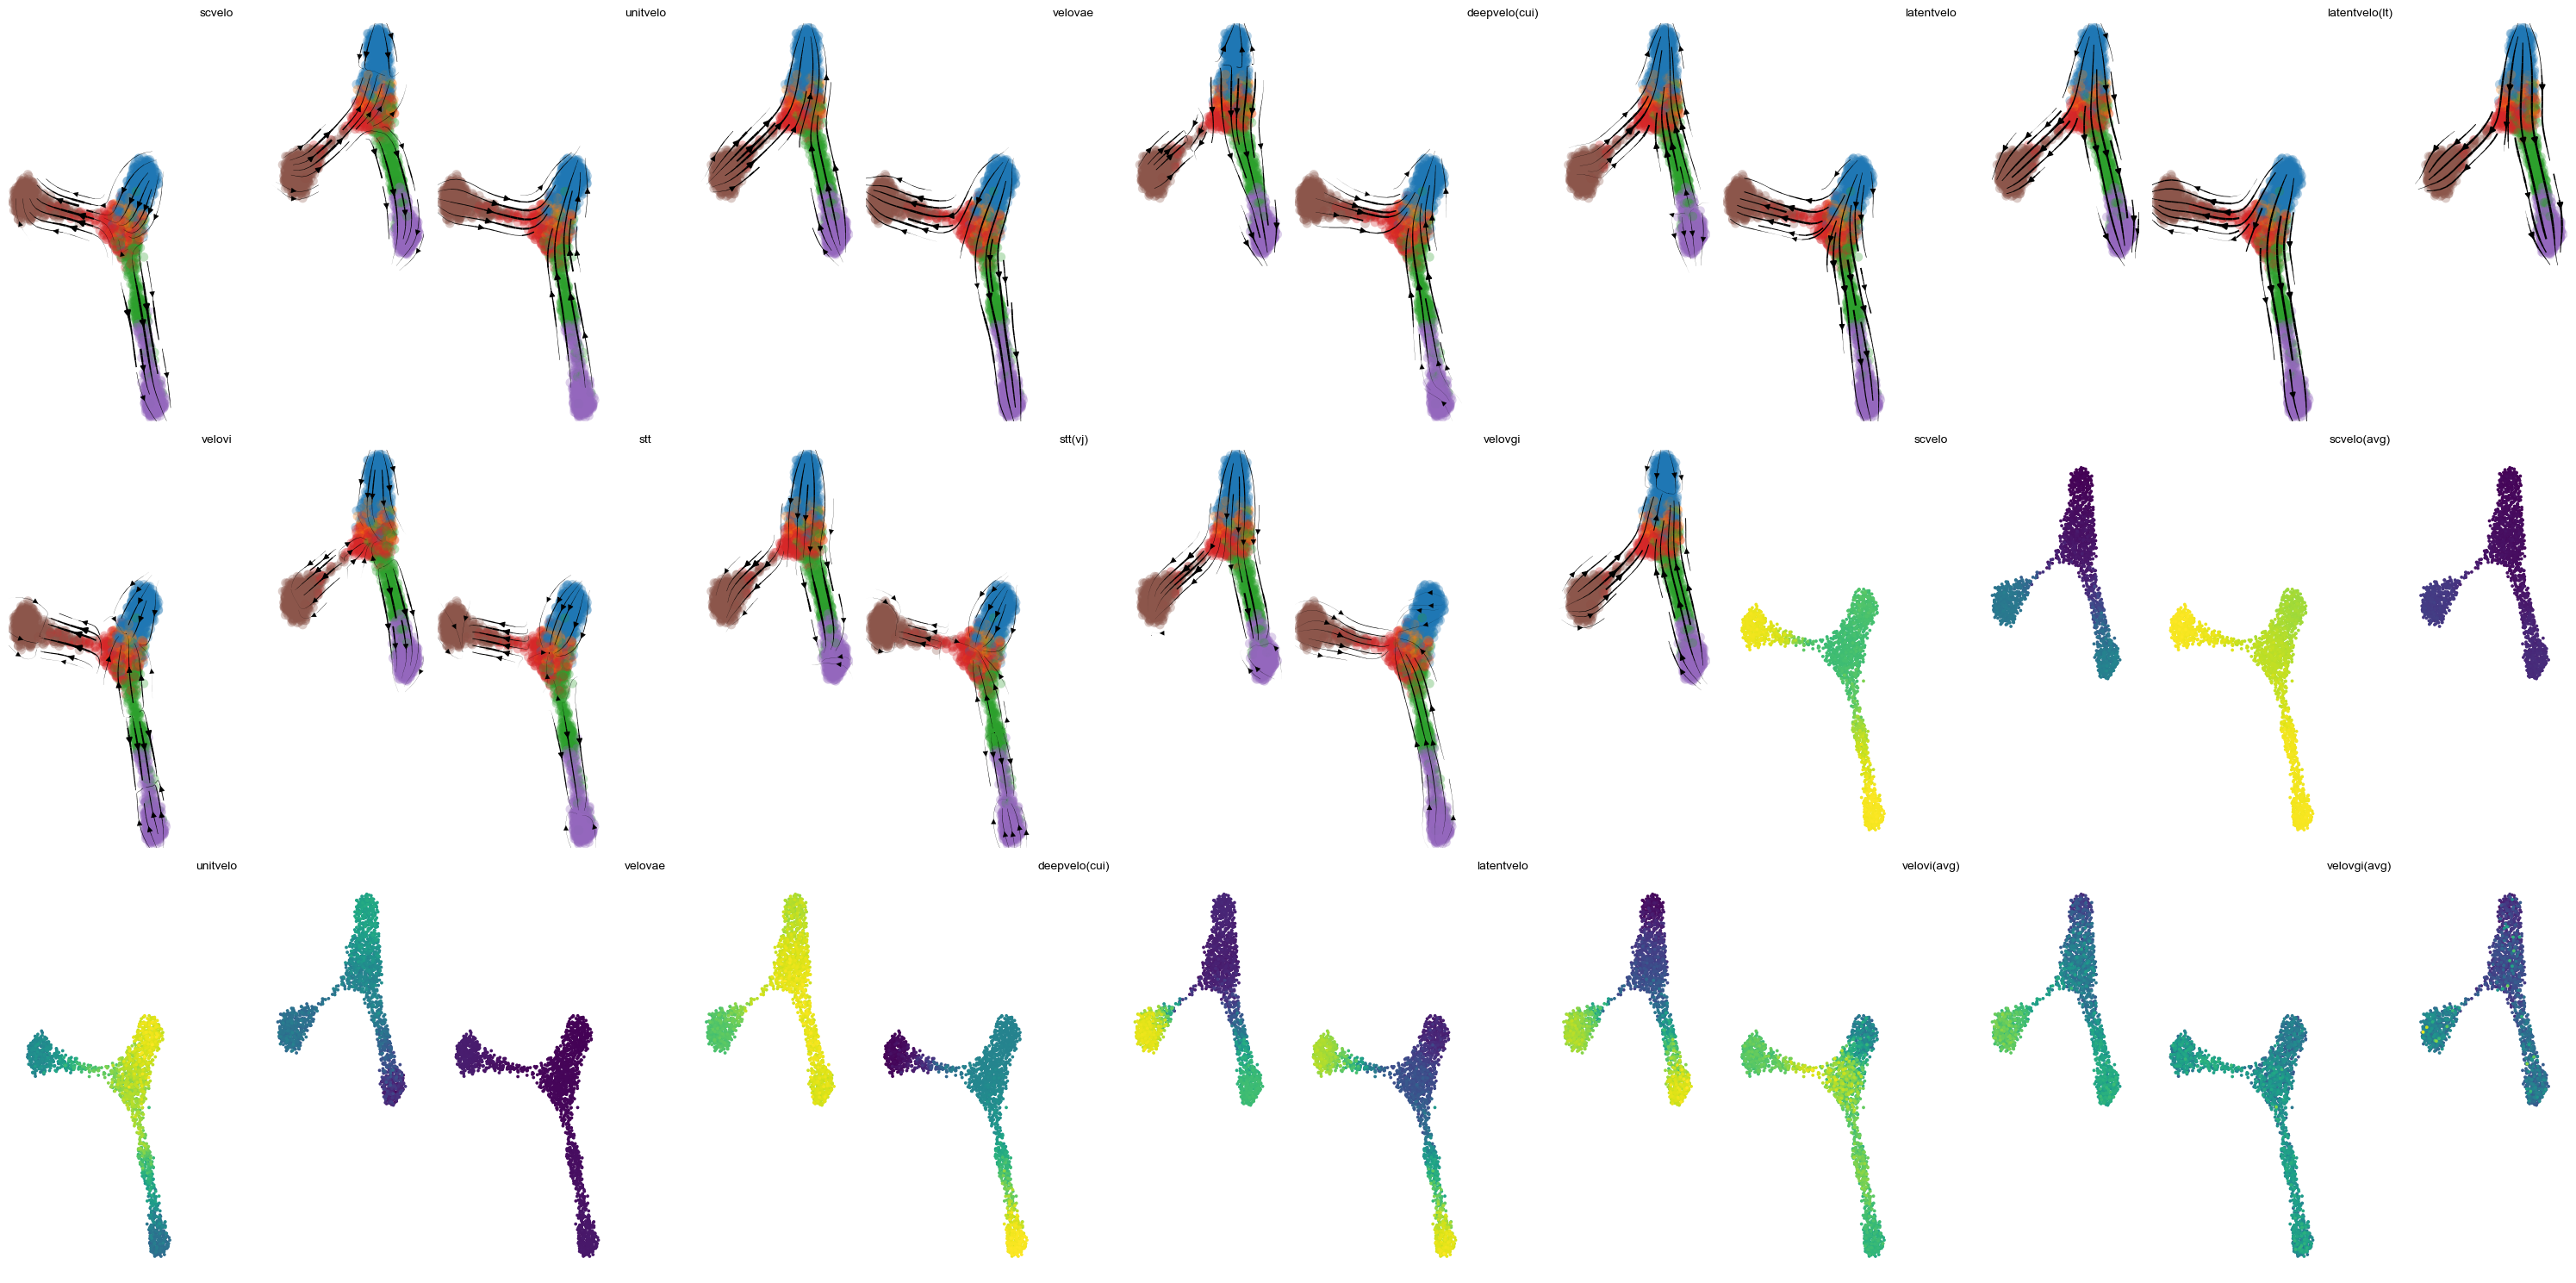

In [7]:
n_rows = 3
n_cols = 6
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
for i, (adata, vkey, title) in enumerate(zip(adata_list, vkey_list, titles)):
    scv.pl.velocity_embedding_stream(
        adata,
        vkey=vkey,
        basis=basis,
        color=cluster_key,
        title=title if title != 'deepvelo_cui' else 'deepvelo(cui)',
        ax=axs[i // n_cols, i % n_cols],
        show=False,
        legend_loc='none',
        # legend_fontsize=8,
        # stream_width=1.5,
        # scale=0.5,
    )
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'velovgi']
i = i + 1
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    vkey = f'{model_name}_velocity'
    adata_path = f'{base_dir}/{data}/{model}/{model_name}.h5ad'
    adata = sc.read_h5ad(adata_path)
    if model == 'scvelo':
        adata = adata[:, adata.var["velocity_genes"]].copy()
    if model == 'unitvelo':
        adata = adata[:, ~np.isnan(adata.layers[vkey]).any(axis=0)].copy()
    # if model == 'topovelo':
    #     adata = adata[(adata.layers[vkey] != 0).any(axis=1)].copy()
    #     del adata.uns['neighbors']
    #     del adata.obsp[spatial_graph_key]
    if model in ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo']:
        tkey = 'pred_t'
        adata.obs[tkey] = scaler.fit_transform(adata.obs[tkey].values.reshape(-1, 1))
        scv.pl.scatter(
            adata,
            basis,
            color=tkey,
            color_map='viridis',
            title=model if model != 'deepvelo_cui' else 'deepvelo(cui)',
            ax=axs[i // n_cols, i % n_cols],
            show=False,
            colorbar=False,
        )
        i = i + 1
    if model in ['scvelo', 'velovi', 'velovgi']:
        t_gene_key = 'fit_t'
        mean_values = np.asarray(adata.layers[t_gene_key].mean(axis=1))
        adata.obs[t_gene_key] = scaler.fit_transform(mean_values.reshape(-1, 1))
        scv.pl.scatter(
            adata,
            basis,
            color=t_gene_key,
            color_map='viridis',
            title=f'{model}(avg)',
            ax=axs[i // n_cols, i % n_cols],
            show=False,
            colorbar=False,
        )
        i = i + 1
plt.tight_layout()
plt.savefig(f'{save_dir}/velocity_stream_time.svg')
plt.show()

Ground Truth

In [9]:
adata_path = '/HDD1/xueweizhi/velocity_benchmark_data/dyngen/batch/dataset_modified.h5ad'
adata = sc.read_h5ad(adata_path)
adata

AnnData object with n_obs × n_vars = 4000 × 535
    obs: 'step_ix', 'simulation_i', 'sim_time', 'model', 'progress', 'milestone'
    var: 'module_id', 'basal', 'burn', 'independence', 'color', 'is_tf', 'is_hk', 'transcription_rate', 'splicing_rate', 'translation_rate', 'mrna_halflife', 'protein_halflife', 'mrna_decay_rate', 'protein_decay_rate', 'max_premrna', 'max_mrna', 'max_protein', 'mol_premrna', 'mol_mrna', 'mol_protein'
    uns: 'model_colors', 'progress_colors', 'traj_dimred_segments', 'traj_milestone_network', 'traj_progressions'
    obsm: 'X_umap', 'dimred'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts', 'rna_velocity', 'spliced', 'unspliced'

In [10]:
scv.pp.filter_and_normalize(adata)
scv.pp.moments(adata, n_neighbors=30, n_pcs=30)

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


computing velocity graph (using 20/104 cores)


  0%|          | 0/4000 [00:00<?, ?cells/s]

100%|██████████| 4000/4000 [00:01<00:00, 2335.09cells/s]


    finished (0:00:03) --> added 
    'rna_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'rna_velocity_umap', embedded velocity vectors (adata.obsm)


/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs/velo_env_new/lib/python3.9/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/xueweizhi/miniconda3/envs

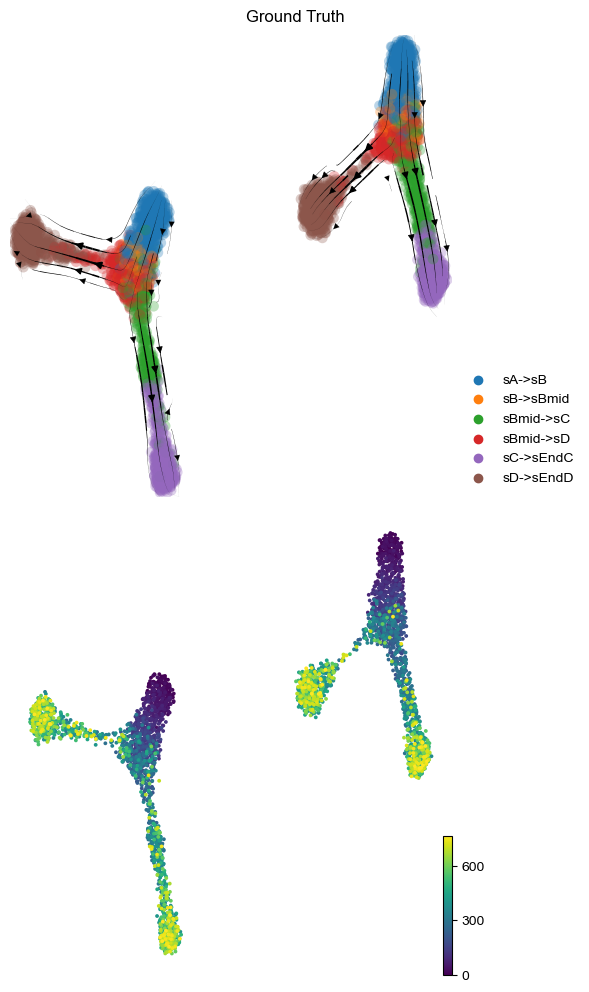

In [11]:
vkey_true = 'rna_velocity'
tkey_true = 'sim_time'
from scipy.sparse import issparse
if issparse(adata.layers[vkey_true]):
    adata.layers[vkey_true] = adata.layers[vkey_true].A
if f'{vkey_true}_graph' not in adata.uns:
    scv.tl.velocity_graph(adata, vkey=vkey_true, n_jobs=20)
fig, axs = plt.subplots(2, 1, figsize=(6, 10))
scv.pl.velocity_embedding_stream(
    adata,
    vkey=vkey_true,
    basis=basis,
    color=cluster_key,
    title='',
    ax=axs[0],
    show=False,
    legend_loc='lower right',
)
scv.pl.scatter(
    adata,
    basis,
    color=tkey_true,
    color_map='viridis',
    title='',
    ax=axs[1],
    show=False,
)
plt.suptitle('Ground Truth')
plt.tight_layout()
plt.savefig(f'{save_dir}/true_velocity_stream_time.svg')
plt.show()